In [1]:
# conda activate meteor
# rm -r venv              
# make first-venv
# make clean
# make virtual-environment
# source venv/bin/activate
# then select the kernel 'venv' in jupyter notebook

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from tqdm import tqdm

In [2]:
cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

### Getting some data that can be used by the forcer engine and ciceroscm

SSP245 for aerorol residual from abrupt-4xCO2

In [3]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt"))
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

standard SSP scenarios

In [4]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]

In [5]:
%%capture
#For predictions: read in SSP concentrations and emissions
#scenarios = ["ssp126","ssp245","ssp370","ssp585"]

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_fwd=[]
em_data_fwd=[]
for i,s in enumerate(scenarios):
    conc_data_fwd.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_fwd.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

SSP534-over

In [6]:
%%capture
#For predictions: read in SSP concentrations and emissions

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_ssp534=[]
em_data_ssp534=[]
for i,s in enumerate(['ssp534-over']):
    conc_data_ssp534.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_ssp534.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

### Getting data for standard scenarios

Getting CMIP6 data from the zarrstore for tas

In [7]:
flds = ["tas","pr"]

In [8]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [9]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [10]:
# remove problematic models when creating the pattern
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))  # drop because bad data
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))  # drop because of data issue
if 'TaiESM1' in models: models.pop(models.index('TaiESM1'))  # drop because of data issue
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))  # drop because of data issue in pr
if 'GISS-E2-1-G' in models: models.pop(models.index('GISS-E2-1-G'))  # drop temperature fit doesn't work
if 'MIROC6' in models: models.pop(models.index('MIROC6'))
if 'MPI-ESM1-2-LR' in models: models.pop(models.index('MPI-ESM1-2-LR'))
if 'FGOALS-g3' in models: models.pop(models.index('FGOALS-g3'))    # data offset between piC and hist
if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))

In [11]:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
        "ssp126": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp126_training_data.nc")),
        "ssp245": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp245_training_data.nc")),
        "ssp370": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp370_training_data.nc")),
        "ssp585": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp585_training_data.nc")),
    }

### Getting data for SSP534-over

In [12]:
data_getter_ssp534 = Cmip6MeteorDataGetter(exps=["piControl", "historical", "ssp534-over", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP'])

models_ssp534 = data_getter_ssp534.models
len(models_ssp534)

12

In [13]:
if 'UKESM1-0-LL' in models_ssp534: models_ssp534.pop(models_ssp534.index('UKESM1-0-LL'))  # ominous data
if 'EC-Earth3' in models_ssp534: models_ssp534.pop(models_ssp534.index('EC-Earth3'))   # data issue (with pr?)
if 'IPSL-CM6A-LR' in models_ssp534: models_ssp534.pop(models_ssp534.index('IPSL-CM6A-LR'))   # nan data issue
if 'FGOALS-g3' in models_ssp534: models_ssp534.pop(models_ssp534.index('FGOALS-g3'))  # data offset between piC and hist

In [14]:
# load locally saved training data
training_data_dict_ssp534={}
for nm,mname in enumerate(models_ssp534):
    #print(nm,mname)

    training_data_dict_ssp534[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
        "ssp534-over": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp534-over_training_data.nc")),
    }

# Create GHG modes and patterns for all selected models

In [15]:
%%capture

CMIP_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 3, "pr": 3},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
            anom_timescales={"tas": 3, "pr": 3}
        )


In [16]:
%%capture
# also capture the spatial response of the last 20 years (2080--2100)

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitude and longitude
target_lats = target_ds.lat
target_lons = target_ds.lon

# Loop over variables and scenarios
patterns_aer_ssp_common_grid_mm = np.zeros([len(scenarios), len(flds), len(target_lats), len(target_lons)])

for nv, var in enumerate(flds):
    for nsc, sc in enumerate(scenarios):
        model_data_list = []

        for nm, mname in enumerate(models):
            # Get native data as an xarray DataArray
            native_ds = CMIP_pattern_dict[mname].predict_from_combined_experiment(
                em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True
            )[var].isel(time=slice(-20, None)).mean(dim='time')

            # Interpolate to the target grid
            regridded_data = native_ds.interp(lat=target_lats, lon=target_lons, method="linear")

            model_data_list.append(regridded_data)

        # Compute model mean
        native_data_mean = xr.concat(model_data_list, dim='model').mean(dim='model')

        # Store in final array
        patterns_aer_ssp_common_grid_mm[nsc, nv, :, :] = np.nansum(native_data_mean,0)

del(model_data_list)
del(CMIP_pattern_dict)

# Application to new scenarios

### SSP534-over

In [17]:
%%capture

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitudes and longitudes
target_lats = target_ds.lat
target_lons = target_ds.lon

# Preallocate final mean array
patterns_ssp534_common_grid_mm = np.zeros([1, len(flds), len(target_lats), len(target_lons)])

# Store predictions
patterns_ssp534 = {}

for nm, mname in enumerate(models_ssp534):
    patterns_ssp534[mname] = {}

    # Create pattern scaling object
    CMIP_pattern_ssp534 = MeteorPatternScaling(
        mname,
        {"tas": 3, "pr": 3},
        lambda key: training_data_dict_ssp534[mname][key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"],
        anom_timescales={"tas": 3, "pr": 3}
    )

    # Process SSP534-over scenario
    sc = "ssp534-over"
    patterns_ssp534[mname][sc] = CMIP_pattern_ssp534.predict_from_combined_experiment(
        em_data_ssp534[0], conc_data_ssp534[0], ["pr", "tas"], return_patterns_per_mode=True
    )

# Interpolation and Model Mean Calculation
for nv, var in enumerate(flds):
    model_data_list = []

    for nm, mname in enumerate(models_ssp534):
        # Extract native data and compute mean over last 20 years
        native_data = np.nanmean(
            np.sum(patterns_ssp534[mname][sc][var].values[:, -20:, :, :], axis=0), axis=0
        )

        # Convert to xarray DataArray
        native_da = xr.DataArray(native_data, dims=["lat", "lon"],
                                 coords={"lat": patterns_ssp534[mname][sc][var].lat,
                                         "lon": patterns_ssp534[mname][sc][var].lon})

        # Interpolate to common grid
        regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")
        model_data_list.append(regridded_data)

    # Compute model mean after interpolation
    native_data_mean = xr.concat(model_data_list, dim="model").mean(dim="model")

    # Store in final array
    patterns_ssp534_common_grid_mm[0, nv, :, :] = native_data_mean.values

del(model_data_list)
del(CMIP_pattern_ssp534)

In [18]:
patterns_ssp534_gm = np.full((len(flds), len(models_ssp534), 6, 251), np.nan)

for nv, var in enumerate(flds):
    for nm, mname in enumerate(models_ssp534):
        # Extract time series
        ts_data = global_mean(training_data_dict_ssp534[mname]['ssp534-over'][var]).values[0, :]
        base_mean = np.nanmean(global_mean(training_data_dict_ssp534[mname]['ssp534-over'][var]).values[0, :50])

        # Determine duration and store
        dur = min(len(ts_data), 251)

        # Process 6 modes for patterns_ssp534_gm
        for mode in range(6):
            patterns_ssp534_gm[nv, nm, mode, :] = global_mean(
                patterns_ssp534[mname]['ssp534-over'][var][mode, 100:, :, :]
            )


### Spatial evaluation

Standard SSPs

In [19]:
%%capture
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitudes and longitudes
target_lats = target_ds.lat
target_lons = target_ds.lon

# Preallocate final mean array
td_ssp_common_grid_mm = np.zeros([len(flds), len(scenarios), len(target_lats), len(target_lons)])

# Loop over variables and scenarios (no model loop needed)
for nv, var in enumerate(flds):
    for nsc, sc in enumerate(scenarios):
        model_data_list = []

        for nm, mname in enumerate(models):
            # Extract native data and compute anomaly
            native_ds = training_data_dict[mname][sc][var]
            native_data = np.nanmean(native_ds.values[0, -20:, :, :], axis=0) - np.nanmean(native_ds.values[0, :50, :, :], axis=0)

            # Convert to xarray DataArray
            native_da = xr.DataArray(native_data, dims=["lat", "lon"], coords={"lat": native_ds.lat, "lon": native_ds.lon})

            # Interpolate to common grid
            regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

            model_data_list.append(regridded_data)

        # Compute model mean after interpolation
        native_data_mean = xr.concat(model_data_list, dim="model").mean(dim="model")

        # Store in final array
        td_ssp_common_grid_mm[nv, nsc, :, :] = native_data_mean.values


SSP534-over

In [20]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp534_common_grid = np.zeros([len(flds),1,len(models_ssp534),len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100
            native_lons = training_data_dict_ssp534[mname][sc][var].lon
            native_lats = training_data_dict_ssp534[mname][sc][var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            td_ssp534_common_grid[nv,nsc,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_97248/1780264212.py:16: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100


## Plotting

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_97248/434562387.py:98: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_97248/434562387.py:108: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid_mm[0,var_idx,:,:]-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())


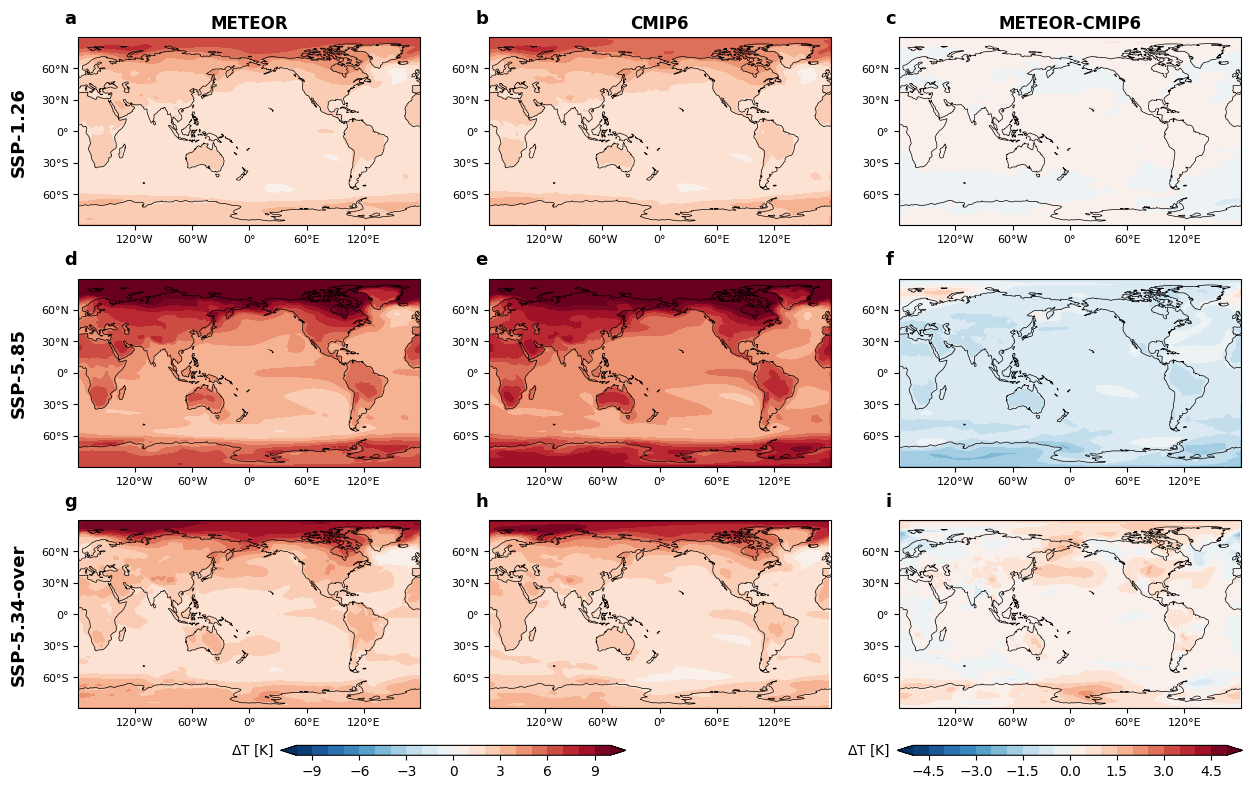

In [22]:
var_idx = 0
levels = np.arange(-10,10.1,1)
cmap="RdBu_r"

fig = plt.figure(figsize=(15,9))
gs = GridSpec(3, 3, figure=fig)

# row 1
sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[0,var_idx,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
#cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
#cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
sub.set_aspect(1.1)
sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, td_ssp_common_grid_mm[var_idx,0,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)  
sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR-CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[0,var_idx,:,:]-td_ssp_common_grid_mm[var_idx,0,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 2
sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[3,var_idx,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats,td_ssp_common_grid_mm[var_idx,3,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1) 
sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[3,var_idx,:,:]-td_ssp_common_grid_mm[var_idx,3,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 3
sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid_mm[0,var_idx,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.241,0.071,"$\Delta$T [K]",ha="center")
sub.set_aspect(1.1)
sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.34-over', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid_mm[0,var_idx,:,:]-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.652,0.071,"$\Delta$T [K]",ha="center")
sub.set_aspect(1.1)
sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_spatial_tas.pdf"), bbox_inches='tight')

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_97248/1150344531.py:98: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_97248/1150344531.py:108: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid_mm[0,var_idx,:,:]-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())


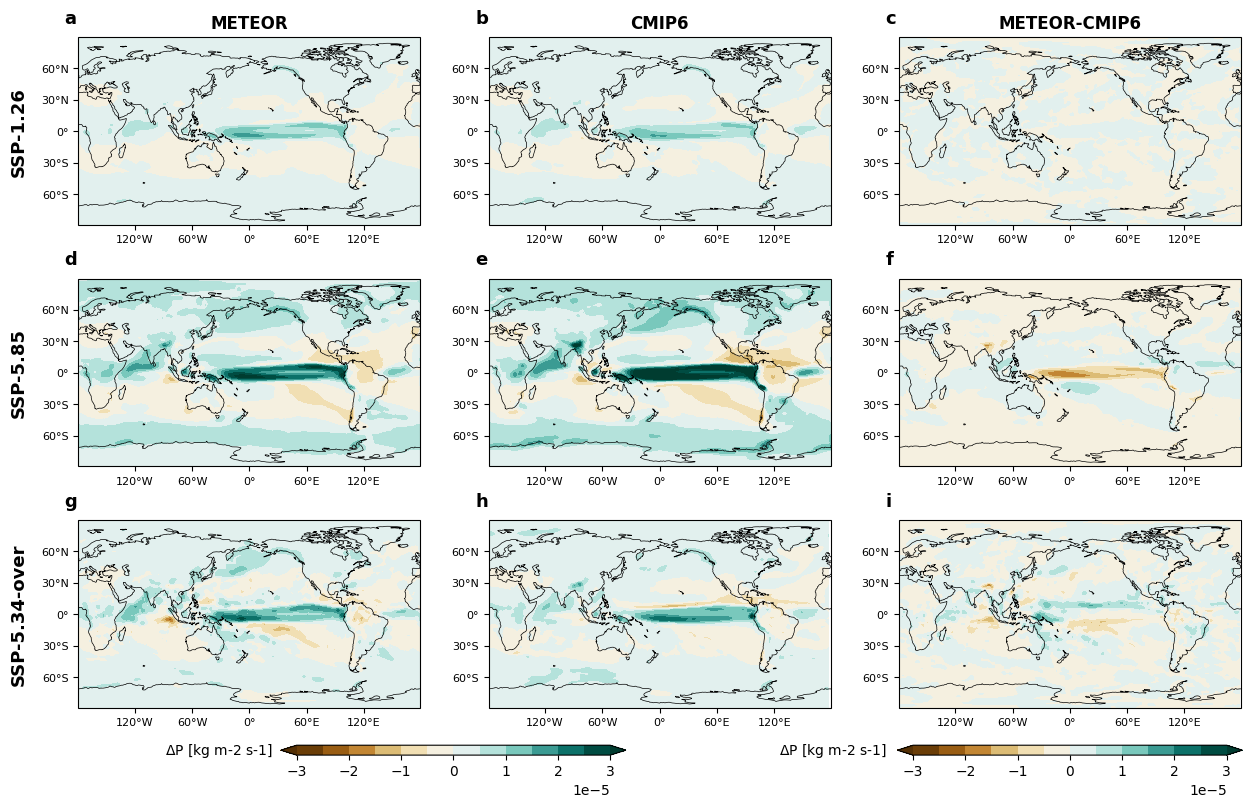

In [28]:
var_idx = 1
levels = np.arange(-3e-5,3.1e-5,0.5e-5)
cmap="BrBG"

fig = plt.figure(figsize=(15,9))
gs = GridSpec(3, 3, figure=fig)

# row 1
sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[0,var_idx,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
#cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
#cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
sub.set_aspect(1.1)
sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, td_ssp_common_grid_mm[var_idx,0,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)  
sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR-CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[0,var_idx,:,:]-td_ssp_common_grid_mm[var_idx,0,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 2
sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[3,var_idx,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, td_ssp_common_grid_mm[var_idx,3,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1) 
sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_aer_ssp_common_grid_mm[3,var_idx,:,:]-td_ssp_common_grid_mm[var_idx,3,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 3
sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid_mm[0,var_idx,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.219,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
sub.set_aspect(1.1)
sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.34-over', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid_mm[0,var_idx,:,:]-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.628,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
sub.set_aspect(1.1)
sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_spatial_pr.pdf"), bbox_inches='tight')

Pattern correlation and RMSE

In [34]:
%%capture

Pcorr = np.zeros([2,5]) * np.nan
Prmse = np.zeros([2,5]) * np.nan

for nv,var in enumerate(flds):
    for nsc,sc in enumerate(scenarios):
        if nsc == 0:
            # Standard SSPs
            array1 = patterns_aer_ssp_common_grid_mm[nsc,nv,:,:].ravel()
            array2 = td_ssp_common_grid_mm[nv,nsc,:,:].ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc] = correlation
            Prmse[nv,nsc] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE
            # SSP534 (and put in higher index)
            array1 = patterns_ssp534_common_grid_mm[nsc,nv,:,:].ravel()
            array2 = np.nanmean(td_ssp534_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc+4] = correlation
            Prmse[nv,nsc+4] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE
        else:
            # Continue with standard SSPs
            array1 = patterns_aer_ssp_common_grid_mm[nsc,nv,:,:].ravel()
            array2 = td_ssp_common_grid_mm[nv,nsc,:,:].ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc] = correlation
            Prmse[nv,nsc] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE


In [35]:
print('tas')
print('Pearson:', Pcorr[0,:])
print('RMSE:', Prmse[0,:])
print('pr')
print('Pearson:', Pcorr[1,:])
print('RMSE:', Prmse[1,:]*1e7)

tas
Pearson: [0.99599723 0.99722035 0.99664523 0.99189658 0.97303037]
RMSE: [0.13041151 0.1883268  0.31838279 0.92528991 0.52961997]
pr
Pearson: [0.97068703 0.9924825  0.98597461 0.96171139 0.76313807]
RMSE: [ 5.38633202  3.93057939  6.88879831 26.35689631 23.96935061]
